# Decision Trees

In our previous lessons, we used geometry, calculus, and probability to make predictions. However, those algorithms share a common flaw: they are "Black Boxes." Try explaining to a CEO that you denied a customer a loan because their "vector fell on the wrong side of a 50-dimensional hyperplane." You will lose their trust instantly.

Enter the **Decision Tree**. This algorithm mimics human logic. It asks a series of sequential "Yes/No" questions until it arrives at a conclusion. It is a "White Box" model—you can print out its exact logical pathway on a piece of paper, trace the decisions with your finger, and explain it to any stakeholder in seconds.

Decision Trees are non-parametric supervised learning algorithms that can be used for both classification and regression. They operate by partitioning (splitting) the feature space into distinct, orthogonal (box-like) regions.

Let's set up our Python environment to crack open this algorithm and look at its mathematical engine.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_moons
from matplotlib.colors import ListedColormap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Logical Tree Environment Ready.")

✅ Logical Tree Environment Ready.


# 1. The Mathematics of Splitting

How does a tree know *which* feature to split on, and at *what exact value*? 
If you are predicting Loan Default, should the first question be "Is Income < $50,000?" or "Is Age < 25?"

The algorithm evaluates every possible split for every single feature and calculates a mathematical score called **Impurity**. The goal of the algorithm is to split the data so that the resulting child nodes are as "pure" as possible (i.e., containing only one class).

There are two primary mathematical formulas used to calculate Impurity.

### 1. Gini Impurity (The Industry Standard)
Gini Impurity measures the probability of incorrectly classifying a randomly chosen element if it were labeled according to the distribution of labels in that node.
$$I_G(p) = 1 - \sum_{i=1}^{c} p_i^2$$
*   $c$ is the number of classes.
*   $p_i$ is the probability (fraction) of items belonging to class $i$ in that node.
*   **Intuition:** If a node contains 100 Legitimate transactions and 0 Fraudulent ones, it is perfectly pure: $1 - (1.0^2 + 0.0^2) = 0$. If it is a 50/50 split, the impurity is $1 - (0.5^2 + 0.5^2) = 0.5$ (the worst possible score).

### 2. Entropy (Shannon's Information Theory)
Borrowed from physics and information theory, Entropy measures the amount of chaos or disorder in a node.
$$H(S) = - \sum_{i=1}^{c} p_i \log_2(p_i)$$
*   **Information Gain:** The tree calculates the Entropy of the parent node, subtracts the weighted average Entropy of the child nodes, and chooses the split that maximizes the Information Gain (the biggest drop in chaos).

*(Note: Scikit-learn uses Gini Impurity by default because calculating logarithms for Entropy is computationally expensive and rarely changes the final tree structure).*

# 2. Visualizing the Tree and the Boundary

Let's simulate a non-linear dataset and watch how a Decision Tree slices it up using orthogonal (horizontal and vertical) cuts.

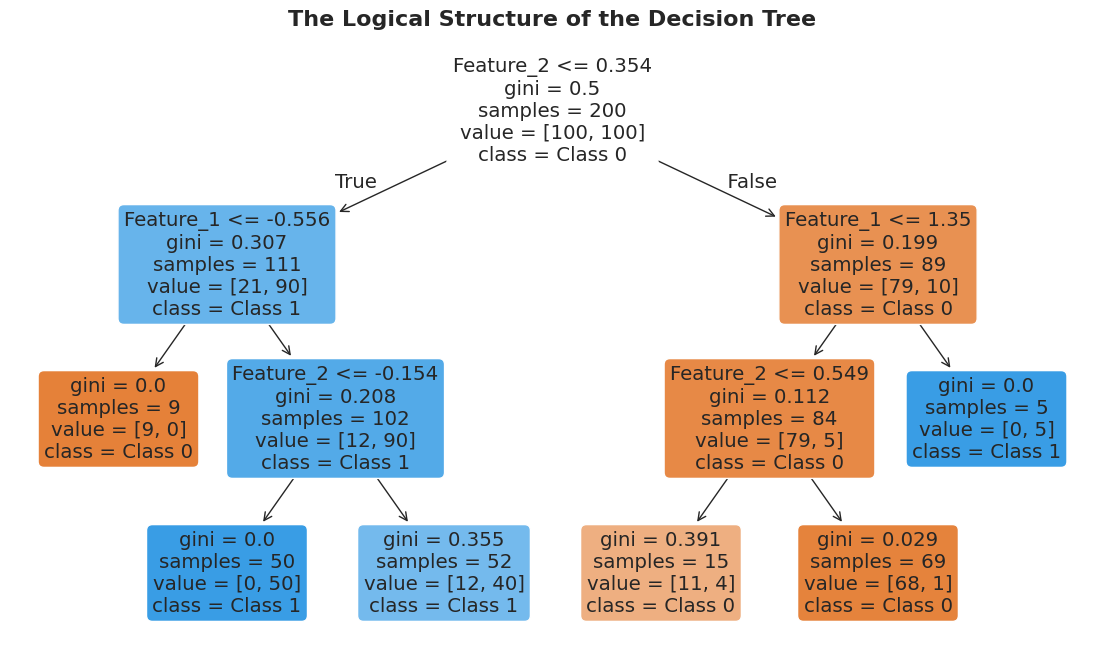

In [2]:
# 1. Simulate complex, non-linear data (Moons)
X, y = make_moons(n_samples=200, noise=0.20, random_state=42)

# 2. Train a Decision Tree Classifier
# We restrict the depth to 3 to keep the math interpretable
tree_clf = DecisionTreeClassifier(max_depth=3, criterion='gini', random_state=42)
tree_clf.fit(X, y)

# 3. Visualize the Actual Logical Tree Structure
plt.figure(figsize=(14, 8))
plot_tree(tree_clf, filled=True, rounded=True, 
          feature_names=['Feature_1', 'Feature_2'], 
          class_names=['Class 0', 'Class 1'], proportion=False)
plt.title("The Logical Structure of the Decision Tree", fontsize=16, fontweight='bold')
plt.show()

*(Insight: Look at the top node (the Root). It evaluates all 200 samples. It found that if it splits `Feature_2` at exactly `0.113`, it achieves the lowest possible Gini impurity for the next step. Notice how the nodes become darker in color as they become more mathematically pure!)*

Now, let's visualize what those exact "Yes/No" splits look like overlaid on top of the data.

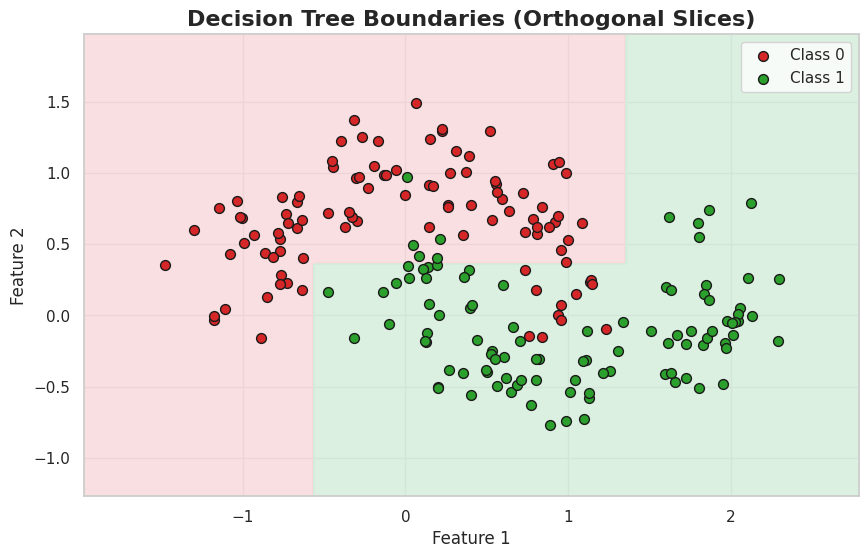

In [3]:
# 4. Visualize the Orthogonal Decision Boundary
plt.figure(figsize=(10, 6))

# Create grid to evaluate model
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the background boundary
cmap_light = ListedColormap(['#f8d7da', '#d4edda'])
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot the raw data
plt.scatter(X[y==0][:, 0], X[y==0][:, 1], color='#d62728', edgecolors='k', label='Class 0', s=50)
plt.scatter(X[y==1][:, 0], X[y==1][:, 1], color='#2ca02c', edgecolors='k', label='Class 1', s=50)

plt.title("Decision Tree Boundaries (Orthogonal Slices)", fontsize=16, fontweight='bold')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

*(Insight: Unlike Logistic Regression (a single straight line) or SVM (smooth curves), the Decision Tree boundary is incredibly blocky. Because it can only split on one feature at a time, its boundaries are strictly horizontal and vertical. It builds a "staircase" to approximate curves).*

# 3. The Fatal Flaw: Overfitting (High Variance)

Decision Trees have a massive vulnerability: **If you do not stop them, they will memorize your entire dataset.** 

If you leave `max_depth=None`, the tree will continue asking "Yes/No" questions until every single node contains exactly 1 data point. It will draw a tiny microscopic box around every single outlier. 

On your training data, it will achieve 100% accuracy. On real-world production data, it will fail catastrophically. This is the definition of **High Variance**.

To prevent this, we must use **Regularization Hyperparameters**:
*   `max_depth`: Forces the tree to stop asking questions after $N$ levels.
*   `min_samples_split`: The node must have at least $N$ samples to justify splitting it further.
*   `min_samples_leaf`: Any terminal node (a leaf) must contain at least $N$ samples. This prevents the tree from creating a leaf for a single outlier.

---

## Real-World Use Case or Analogy:
Think of a Decision Tree like playing the game **"20 Questions"**:

*   **The Goal**: Guess the animal I am thinking of (The Target Variable $y$).
*   **The Features ($X$)**: Size, color, diet, habitat, number of legs.
*   **The Algorithm (Information Gain)**: If your first question is *"Does it have a scar on its left knee?"*, that is a terrible question. The Information Gain is basically zero. A mathematically optimal player asks *"Is it a mammal?"* because that single question splits the entire animal kingdom exactly in half, destroying the maximum amount of entropy (chaos) in the system.
*   **Overfitting**: If you ask 50 hyper-specific questions to guess the animal, you haven't learned what a dog is; you have just memorized the exact description of *my specific dog*. If a new dog walks in, your rigid rules won't recognize it. You must limit your questions (`max_depth`) to learn generalizable rules.

---